<a href="https://colab.research.google.com/github/analauralopescapeletto-sketch/AULA-CN/blob/main/calculo_numerico_atv2ana.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cálculo Numérico — Atividade Prática II
## Estabilidade e Overflow

**Objetivo:** investigar a relação entre estabilidade numérica, passo de tempo e ocorrência de overflow em uma simulação simplificada de dinâmica dos fluidos computacional (escoamento de Couette).
`Dupla: Ana Laura Lopes Capeletto e Ranielly Hissamori`


## 1. Verificação da estabilidade (Atividade 1)

Dados fixos: H = 0,01 m, ν = 10⁻⁴ m²/s, 21 pontos.

Δy = H/(21−1) = 0,01/20 = **0,0005 m**

Δt_max = Δy² / (2ν) = (0,0005)² / (2×10⁻⁴) = **0,00125 s**

| Caso | Δt (s) | r = νΔt/Δy² | Classificação |
|---|---|---|---|
| A | 0,001 | 0,40 | **Estável** (r ≤ 0,5) |
| B | 0,002 | 0,80 | **Instável** (r > 0,5) |

O Caso A tem coeficiente central (1−2r) = 0,20 (positivo → média ponderada válida). O Caso B tem (1−2r) = −0,60 (negativo → permite oscilações amplificadas).

In [1]:
import numpy as np

H = 0.01
nu = 1e-4

for pontos in (21, 41):
    dy = H / (pontos - 1)
    dt_max = dy**2 / (2 * nu)
    print(f"pontos={pontos}: dy={dy}, dt_max={dt_max}")

for dt in (0.001, 0.002):
    dy = H / (21 - 1)
    r = nu * dt / dy**2
    print(f"dt={dt}: r={r}")

pontos=21: dy=0.0005, dt_max=0.0012499999999999998
pontos=41: dy=0.00025, dt_max=0.00031249999999999995
dt=0.001: r=0.4000000000000001
dt=0.002: r=0.8000000000000002


## 2. Função de simulação e execução dos quatro testes (Atividade 2)

Código original: registra a maior velocidade em módulo a cada passo e interrompe a simulação quando detecta overflow ou operação inválida.

In [2]:
import numpy as np
import matplotlib.pyplot as plt


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


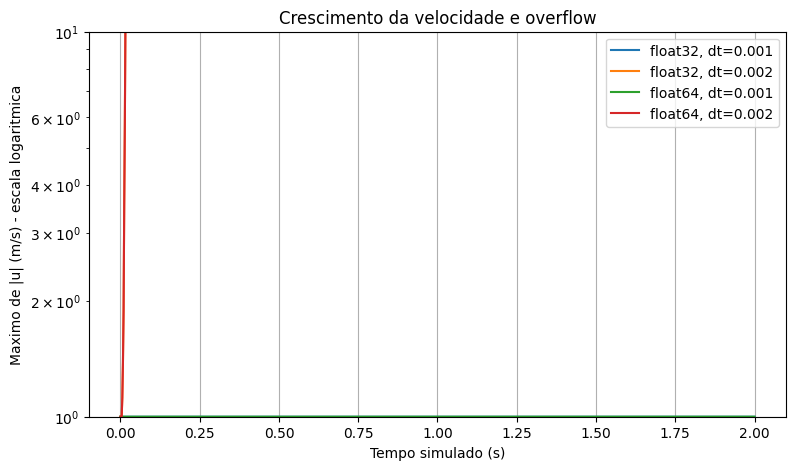

In [3]:
plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

### Tabela de resultados (Atividade 2)

| Tipo numérico | Δt (s) | r | Overflow? | Passo da falha | Tempo da falha |
|---|---|---|---|---|---|
| float32 | 0,001 | 0,40 | Não | — | — |
| float32 | 0,002 | 0,80 | **Sim** | 121 | t = 0,2420 s |
| float64 | 0,001 | 0,40 | Não | — | — |
| float64 | 0,002 | 0,80 | **Sim** | 917 | t = 1,8340 s |

In [4]:
# Monta a tabela automaticamente a partir dos resultados obtidos acima
import pandas as pd

linhas = []
for nome, resultado in resultados.items():
    tipo_nome, dt_str = nome.split(", ")
    linhas.append({
        "tipo": tipo_nome,
        "dt": float(dt_str.replace("dt=", "")),
        "r": resultado["r"],
        "overflow": resultado["falha"] is not None,
        "passo_falha": resultado["falha"],
        "tempo_falha": None if resultado["falha"] is None else resultado["tempos"][-1] if resultado["falha"] else None,
    })

tabela = pd.DataFrame(linhas)
tabela

,tipo,dt,r,overflow,passo_falha,tempo_falha
0,float32,0.001,0.4,False,NaN,NaN
1,float32,0.002,0.8,True,121.0,0.240
2,float64,0.001,0.4,False,NaN,NaN
3,float64,0.002,0.8,True,917.0,1.832


## 3. Interpretação física (Atividade 3)

O gráfico (escala log em y) mostra duas curvas praticamente constantes em torno de |u| = 1 m/s (casos com r = 0,4) e duas curvas que sobem em linha quase reta na escala logarítmica antes de dispararem para overflow (casos com r = 0,8) — esse crescimento em linha reta no gráfico log é a assinatura de um **crescimento exponencial**, típico de instabilidade numérica.

Fisicamente, a velocidade só pode variar entre 0 e U = 1 m/s: o fluido é arrastado pela placa e nunca pode ultrapassar a velocidade da placa que o arrasta, pois não há fonte de energia adicional no problema. Um valor de |u| muito maior que 1 não corresponde a nenhum fenômeno físico real — é um artefato puramente numérico. Ele surge porque, com r > 1/2, o coeficiente (1 − 2r) da fórmula de atualização fica negativo: em vez de calcular uma média ponderada dos vizinhos (que sempre produz um valor entre os valores vizinhos), o esquema passa a **amplificar** qualquer diferença entre pontos adjacentes a cada passo de tempo. Pequenos erros de arredondamento (inevitáveis em ponto flutuante) são amplificados repetidamente, dobrando (ou mais) a cada iteração, até que o valor ultrapasse a capacidade de representação do tipo numérico e ocorra o overflow.

## 4. Capacidade de representação (Atividade 4)

Comparando os casos com r = 0,8:

- **float32** falha no passo 121 (t ≈ 0,242 s).
- **float64** falha no passo 917 (t ≈ 1,834 s).

A mudança de tipo numérico **não elimina a instabilidade** — em ambos os casos a solução diverge e eventualmente ocorre overflow. O que muda é apenas **quanto tempo leva até que a divergência seja grande o suficiente para estourar a faixa representável**.

Isso ocorre porque float64 tem uma faixa de representação muito maior (≈ 1,8×10³⁰⁸) que float32 (≈ 3,4×10³⁸) — cerca de 270 ordens de grandeza a mais. Como o erro cresce exponencialmente (multiplicado por um fator constante a cada passo), atingir um limite ~270 ordens de grandeza maior exige proporcionalmente mais iterações. Mas o crescimento exponencial garante que, mais cedo ou mais tarde, qualquer limite finito será ultrapassado. Ou seja: **float64 apenas atrasa o sintoma (overflow); não corrige a causa (r > 1/2)**. A solução já estava fisicamente incorreta bem antes do overflow aparecer — só demorou mais para 'estourar' com mais bits de precisão.

## 5. Refinamento da malha (Atividade 5)

Com `pontos=41`:

Δy = H/(41−1) = 0,01/40 = **0,00025 m**

Δt_max = Δy²/(2ν) = (0,00025)²/(2×10⁻⁴) = **0,0003125 s**

Mantendo Δt = 0,001 s (o mesmo do Caso A original):

r = νΔt/Δy² = (10⁻⁴ × 0,001)/(0,00025²) = **1,6** → instável (r ≫ 0,5).

In [5]:
resultado_41_instavel = simular(0.001, np.float64, passos=2000, pontos=41)
print("r =", resultado_41_instavel["r"])
print("falha no passo:", resultado_41_instavel["falha"])

dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
r = 1.6000000000000003
falha no passo: 426


Como esperado, r = 1,6 gera instabilidade: o mesmo Δt que era estável com 21 pontos deixa de ser estável com 41 pontos, porque r depende de Δy ao quadrado. Dobrar a resolução espacial (Δy pela metade) exige reduzir Δt por um fator de 4 para manter r constante.

**Escolhendo um Δt abaixo do novo limite** (Δt_max = 0,0003125 s), por exemplo Δt = 0,0001 s (r = 0,16):

In [6]:
resultado_41_estavel = simular(0.0001, np.float64, passos=5000, pontos=41)
print("r =", resultado_41_estavel["r"])
print("falha no passo:", resultado_41_estavel["falha"])

dt=0.0001, float64: 5000 passos sem overflow.
r = 0.16
falha no passo: None


Com r = 0,16 (abaixo de 0,5), a simulação roda os 5000 passos sem overflow, confirmando a previsão teórica de estabilidade.

## 6. Verificação do perfil de velocidade (Atividade 6)

Executando uma simulação estável e suficientemente longa (Caso A: 21 pontos, Δt = 0,001 s, float64, 3000 passos → t final = 3,0 s) e comparando com o perfil estacionário:

$$u_{est}(y) = U\left(1 - \frac{y}{H}\right)$$

In [9]:
res_estacionario = simular(0.001, np.float64, passos=3000, pontos=21)

U = 1.0
u_est = U * (1 - res_estacionario["y"] / H)
E_inf = np.max(np.abs(res_estacionario["u"] - u_est))

print("Tempo final simulado:", res_estacionario["tempos"][-1], "s")
print("u final       :", np.round(res_estacionario["u"], 6))
print("u estacionario:", np.round(u_est, 6))
print("E_infinito =", E_inf, "m/s")

dt=0.001, float64: 3000 passos sem overflow.
Tempo final simulado: 3.0 s
u final       : [1.   0.95 0.9  0.85 0.8  0.75 0.7  0.65 0.6  0.55 0.5  0.45 0.4  0.35
 0.3  0.25 0.2  0.15 0.1  0.05 0.  ]
u estacionario: [1.   0.95 0.9  0.85 0.8  0.75 0.7  0.65 0.6  0.55 0.5  0.45 0.4  0.35
 0.3  0.25 0.2  0.15 0.1  0.05 0.  ]
E_infinito = 8.08242361927114e-14 m/s


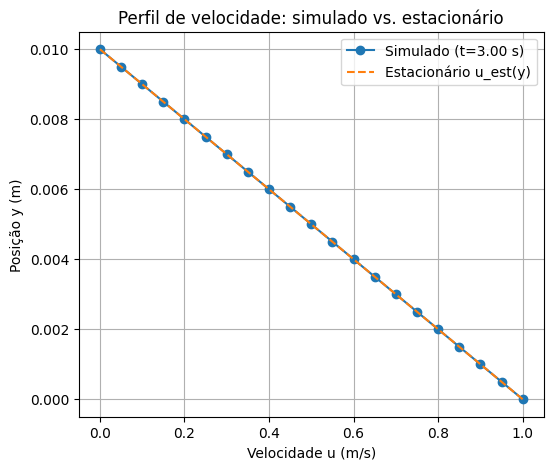

In [8]:
plt.figure(figsize=(6, 5))
plt.plot(res_estacionario["u"], res_estacionario["y"], "o-",
         label=f"Simulado (t={res_estacionario['tempos'][-1]:.2f} s)")
plt.plot(u_est, res_estacionario["y"], "--", label="Estacionário u_est(y)")
plt.xlabel("Velocidade u (m/s)")
plt.ylabel("Posição y (m)")
plt.title("Perfil de velocidade: simulado vs. estacionário")
plt.legend()
plt.grid(True)
plt.show()

**Discussão:** E∞ é da ordem de 10⁻¹⁴ m/s, ou seja, essencialmente zero — é o próprio erro de arredondamento de ponto flutuante em float64 (precisão de máquina ~10⁻¹⁶). Isso indica que, para t = 3 s, o regime **já é estacionário** — a diferença observada não reflete um transiente inacabado, e sim ruído numérico.

Isso é coerente com a escala de tempo característica de difusão do problema, τ ≈ H²/ν = (0,01)²/10⁻⁴ = 1 s: em t = 3 s (≈ 3τ), o transiente já decaiu totalmente. Se a simulação fosse interrompida bem mais cedo (t ≪ 1 s), E∞ seria maior e refletiria um transiente genuíno, ainda em andamento, e não apenas erro numérico.

## 7. Conclusão (Atividade 7)

O esquema explícito usado (Euler no tempo, diferenças centrais no espaço) só é estável quando r = νΔt/Δy² ≤ 1/2. Essa condição liga diretamente três grandezas do problema:

- **Refinar a malha** (reduzir Δy) aumenta a resolução espacial, mas reduz Δt_max proporcionalmente ao **quadrado** de Δy — malhas mais finas exigem passos de tempo desproporcionalmente menores para permanecer estáveis.
- **Passo de tempo grande demais** (r > 1/2) faz o coeficiente central da atualização ficar negativo, transformando o esquema, que deveria calcular uma média ponderada, em um amplificador de erros: qualquer perturbação (inclusive o próprio arredondamento de ponto flutuante) cresce exponencialmente a cada iteração.
- **Overflow** é apenas a consequência tardia e visível dessa instabilidade: é o momento em que o valor amplificado ultrapassa a faixa representável do tipo numérico usado. A causa raiz é a instabilidade (r > 1/2); o overflow é só o sintoma final. Trocar float32 por float64 apenas adia o overflow, mas não corrige o problema — a solução já é fisicamente inválida muito antes do overflow acontecer.

**A correção real da falha nesta simulação** não é mudar o tipo numérico, e sim **reduzir o passo de tempo até satisfazer r ≤ 1/2** para a malha escolhida (por exemplo, Δt = 0,001 s para 21 pontos, ou Δt = 0,0001 s para 41 pontos). Feita essa correção, a simulação permanece estável, a velocidade máxima nunca ultrapassa fisicamente U = 1 m/s, e o perfil final converge para a solução estacionária esperada u_est(y) = U(1 − y/H), com erro da ordem do arredondamento de máquina (~10⁻¹⁴).

### Resumo dos valores-chave

| Grandeza | Valor |
|---|---|
| Δy (21 pontos) | 0,0005 m |
| Δt_max (21 pontos) | 0,00125 s |
| r Caso A (Δt=0,001) | 0,40 (estável) |
| r Caso B (Δt=0,002) | 0,80 (instável) |
| Falha float32, Caso B | passo 121, t=0,2420 s |
| Falha float64, Caso B | passo 917, t=1,8340 s |
| Δy (41 pontos) | 0,00025 m |
| Δt_max (41 pontos) | 0,0003125 s |
| r (41 pontos, Δt=0,001) | 1,60 (instável) |
| Falha (41 pontos, Δt=0,001) | passo 426, t=0,4260 s |
| r (41 pontos, Δt=0,0001, corrigido) | 0,16 (estável) |
| E∞ (21 pontos, t=3 s) | ≈ 8,08 × 10⁻¹⁴ m/s |